<a href="https://colab.research.google.com/github/CPernet/Identification_-likelihood_in_NeuroImaging_data/blob/main/ratings_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Analysis of the expert rating on neuroimaging data type privacy**

*   the sheet contain the rating from 20 experts
*   the columns order is rating ability to identify then ability to single out, and this pattern is repeated over 33 items

In [ ]:
import pandas as pd
from google.colab import auth
import gspread
import google.auth

# Authenticate with Google Colab
auth.authenticate_user()

# Authorize gspread using OAuth (user credentials)
try:
    # Get the default credentials from authenticated user
    creds, project = google.auth.default()

    # Initialize gspread client with the obtained credentials
    gc = gspread.Client(auth=creds)

    # Open the Google Sheet by its title
    spreadsheet = gc.open("DELPHI-merged")
    # Get all worksheets. You might need to specify a particular worksheet if the sheet has multiple tabs.
    # For simplicity, we'll get the first worksheet.
    worksheet = spreadsheet.sheet1 # or spreadsheet.worksheet("Sheet Name")

    # Get all values as a list of lists
    data = worksheet.get_all_values()

    # Convert to pandas DataFrame
    # Assuming the first row contains headers
    df = pd.DataFrame(data[1:], columns=data[0])

    print("Google Sheet 'DELPHI-merged' imported successfully into DataFrame 'df'.")
    # Removed: print(df.head())
except gspread.exceptions.SpreadsheetNotFound:
    print("Error: Google Sheet 'DELPHI-merged' not found. Please ensure the name is correct and you have access.")
except Exception as e:
    print(f"An error occurred: {e}")

Google Sheet 'DELPHI-merged' imported successfully into DataFrame 'df'.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Separate columns based on the 'identify' then 'single out' pattern
# Assuming the pattern repeats for the first 66 columns (33 items * 2 columns per item)

# Get indices for 'ability to identify' columns (0-indexed even positions)
identify_cols_indices = [i for i in range(66) if i % 2 == 0]
# Get indices for 'ability to single out' columns (0-indexed odd positions)
singleout_cols_indices = [i for i in range(66) if i % 2 != 0]

# Create DataFrames for identify and single out ratings
df_identify_ratings = df.iloc[:, identify_cols_indices]
df_singleout_ratings = df.iloc[:, singleout_cols_indices]



/tmp/ipykernel_776/2787759047.py:38: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


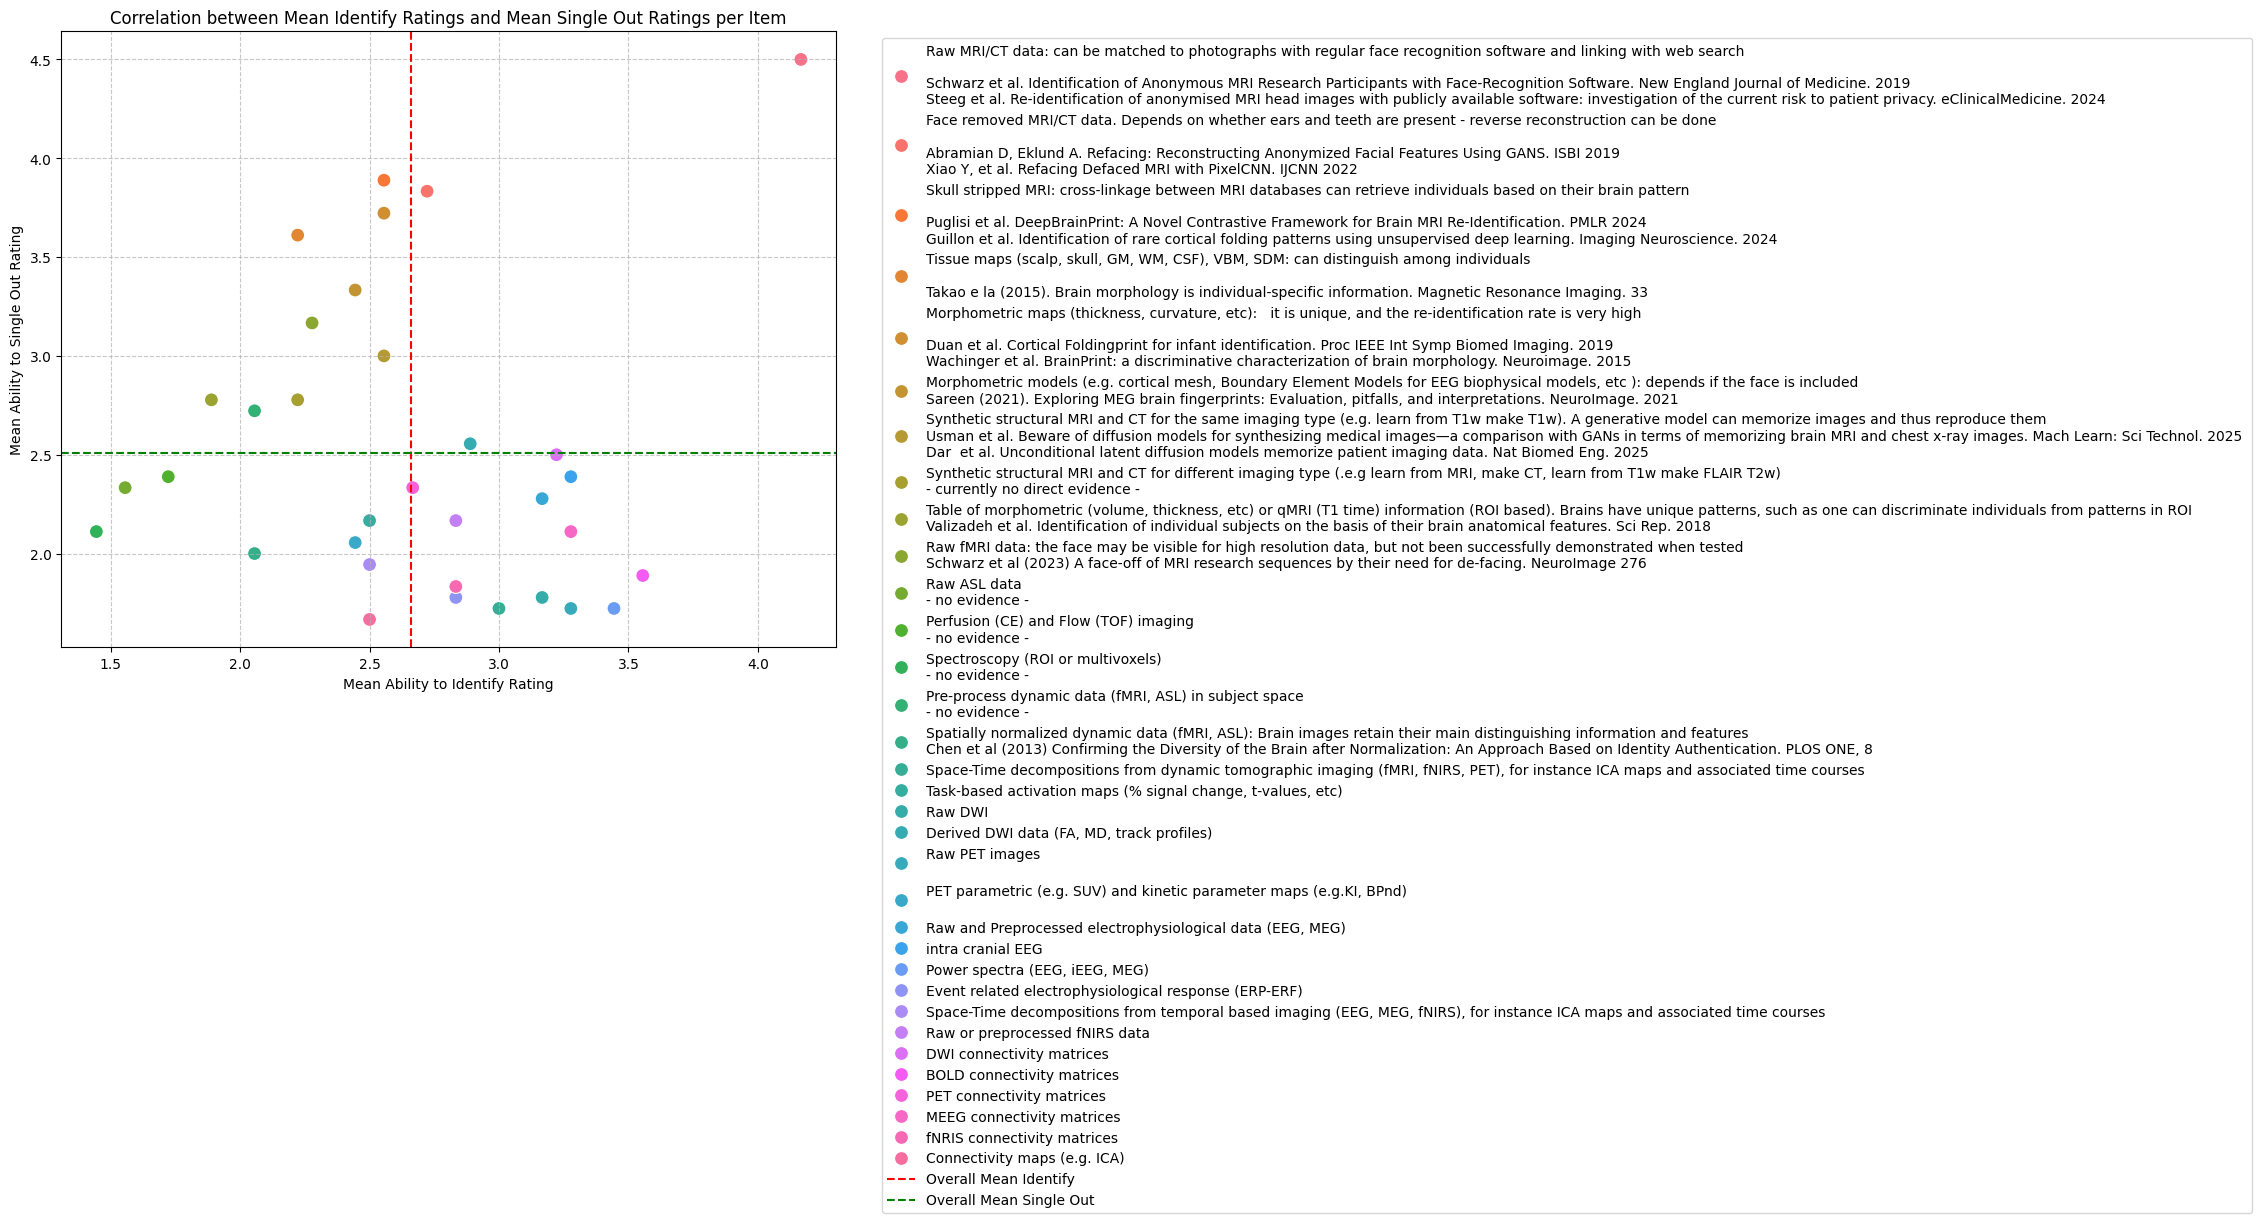

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compute the mean of each column for df_identify_ratings
mean_identify_ratings = df_identify_ratings.astype(float).mean()

# Compute the mean of each column for df_singleout_ratings
mean_singleout_ratings = df_singleout_ratings.astype(float).mean()

# Ensure both series have the same index (item names) and are aligned
# This step is important if column names are not identical, though they should be similar for this context
# For simplicity, we'll assume they are aligned by their original column order from df

# Create a DataFrame for plotting
mean_ratings_df = pd.DataFrame({
    'Mean Identify Rating': mean_identify_ratings.values,
    'Mean Single Out Rating': mean_singleout_ratings.values
})

# Create the scatter plot
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='Mean Identify Rating',
    y='Mean Single Out Rating',
    data=mean_ratings_df,
    s=100, # size of points
    hue=mean_identify_ratings.index, # Color points by item (column name)
    legend='full'
)

plt.title('Correlation between Mean Identify Ratings and Mean Single Out Ratings per Item')
plt.xlabel('Mean Ability to Identify Rating')
plt.ylabel('Mean Ability to Single Out Rating')
plt.grid(True, linestyle='--', alpha=0.7)
plt.axvline(mean_identify_ratings.mean(), color='red', linestyle='--', label='Overall Mean Identify')
plt.axhline(mean_singleout_ratings.mean(), color='green', linestyle='--', label='Overall Mean Single Out')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Place legend outside the plot
plt.tight_layout()
plt.show()

This heatmap visualizes the difference between each expert's 'ability to identify' rating and their corresponding 'ability to single out' rating for each item.

*   **Red shades** indicate that the 'ability to identify' rating was *higher* than the 'ability to single out' rating.
*   **Blue shades** indicate that the 'ability to identify' rating was *lower* than the 'ability to single out' rating.
*   **White/light colors** suggest little to no difference between the two ratings.

This can help pinpoint specific items or experts where there's a significant disparity in these two types of ratings.